In [2]:
import sys
import os

# Проверяем, запущен ли ноутбук в среде Google Colab
if "google.colab" in sys.modules:
    !pip install uv -q
    !wget https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_1/pyproject.toml -q
    !uv pip install -r pyproject.toml --system -q
    os.kill(os.getpid(), 9)  # force runtime restart

# Курс по прогнозированию временных рядов
# Неделя 3.
# Фильтрация и прогноз в ETS

Три следующих ноутбука этой недели (`01`, `02`, `03`) сразу вызывают модели ETS
и сравнивают их по MAPE. Это полезно, но оставляет дыру: `.level`, `.fittedvalues`,
`.params`, `summary()` — фреймворк возвращает много чисел, и не всегда понятно,
какое из них что означает и откуда берётся.

Здесь мы закрываем эту дыру **до** знакомства с фреймворками. Разберём три модели
семейства ETS — простое экспоненциальное сглаживание (SES), модель Хольта
и модель Хольта-Винтерса — с двух сторон:

* **руками**, на ряде из 5–8 чисел, которые можно пересчитать в столбик;
* через `statsmodels`, построчно сверяя каждое возвращаемое число с ручным расчётом.

## Что мы разберём

| Раздел | Вопрос, на который отвечаем |
|---|---|
| 0 | Чем «фильтрация» отличается от «прогноза» и что такое состояние ETS-модели |
| 1 | SES: рекурсия по одному числу-уровню |
| 2 | Модель Хольта: рекурсия по уровню и тренду, демпфирование |
| 3 | Хольт-Винтерс: добавляем сезонность, фильтрация на реальных данных |
| 4 | `ETSModel`: как читать `summary()`, доверительные интервалы, симуляции |

Разделы 1–3 устроены одинаково, по одному и тому же шаблону — так проще
видеть, что меняется от модели к модели, а что остаётся общим:

1. **Теория** — уравнение прогноза и уравнения сглаживания;
2. **Рекурсия руками** — таблица $y_t, \hat{y}_t, e_t$ и компоненты состояния;
3. **Сверка фильтрации** — `.level` / `.trend` / `.season` / `.fittedvalues` /
   `.resid` против ручного расчёта;
4. **Сверка прогноза** — `.forecast(h)` против уравнения прогноза, посчитанного
   руками;
5. **Разложение прогноза на компоненты** — из каких слагаемых (или множителей)
   складывается каждая точка прогноза.


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.tsa.holtwinters import ExponentialSmoothing, Holt, SimpleExpSmoothing

# Чуть более крупные и читаемые графики по умолчанию.
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 110

import statsmodels

print("statsmodels:", statsmodels.__version__)
print("pandas:     ", pd.__version__)
print("numpy:      ", np.__version__)

statsmodels: 0.14.6
pandas:      2.3.3
numpy:       2.4.6


Одна вспомогательная функция, которой мы будем пользоваться во всех трёх
разделах: она рисует, из каких компонент складывается прогноз. Компоненты
передаются списком троек `(подпись, значения, операция)`, где операция —
`"base"` (первая, опорная компонента), `"add"` (прибавляется) или `"mul"`
(умножается). Функция накапливает компоненты по очереди и закрашивает
полосу между «было» и «стало» — площадь полосы и есть вклад компоненты.

In [4]:
def plot_forecast_decomposition(forecast, components, title, history=None, ax=None):
    """Показать, из каких компонент складывается прогноз ETS.

    forecast   — итоговый прогноз ŷ_{T+h|T} (Series);
    components — список (подпись, значения, операция), операция ∈ {"base", "add", "mul"};
    history    — последние наблюдения обучающей выборки (рисуются слева, опционально).
    """
    if ax is None:
        _, ax = plt.subplots()

    index = forecast.index
    cumulative = np.zeros(len(forecast))
    for label, values, op in components:
        values = np.broadcast_to(np.asarray(values, dtype=float), (len(forecast),))
        previous = cumulative
        if op == "base":
            cumulative = values
        elif op == "add":
            cumulative = cumulative + values
        elif op == "mul":
            cumulative = cumulative * values
        else:
            raise ValueError(f"неизвестная операция: {op!r}")
        ax.fill_between(index, previous, cumulative, alpha=0.35, label=label)
        ax.plot(index, cumulative, linewidth=1, color="gray")

    if history is not None:
        history.plot(ax=ax, marker="o", color="black", label="наблюдения (train)")
    forecast.plot(ax=ax, marker="o", color="crimson", linewidth=2, label="итоговый прогноз")

    # Проверяем, что накопленные компоненты действительно дают прогноз.
    np.testing.assert_allclose(cumulative, forecast.to_numpy(), rtol=1e-10)

    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8)
    return ax

---
# 0. Фильтрация против прогнозирования

## 0.1. Два разных вопроса к одному ряду

Пусть у нас есть ряд наблюдений $y_1, y_2, \dots, y_T$. К нему можно задать
два вопроса.

* **Фильтрация**: «каков сейчас настоящий уровень ряда, если убрать шум
  наблюдения?» Вопрос о **прошлом и настоящем** — у нас уже есть $y_t$,
  мы хотим очистить его от случайного колебания.
* **Прогнозирование**: «что будет через $h$ шагов, если данных за это время
  ещё нет?» Вопрос о **будущем** — наблюдений $y_{T+1}, \dots, y_{T+h}$ попросту
  не существует.


## 0.2. Скрытое состояние

Модели ETS устроены как **пространство состояний** (state space): у ряда есть
ненаблюдаемое состояние, и наблюдение $y_t$ — это состояние плюс шум.

$$ y_t = \underbrace{w(x_{t-1})}_{\text{сигнал}} + \underbrace{\varepsilon_t}_{\text{шум}} $$

Состояние $x_t$ в разных моделях ETS состоит из разных частей:

| Модель | Состояние $x_t$ |
|---|---|
| SES — ETS(A,N,N) | уровень $l_t$ |
| Хольт — ETS(A,A,N) | уровень $l_t$ и тренд $b_t$ |
| Хольт-Винтерс — ETS(A,A,A) | уровень $l_t$, тренд $b_t$, сезонность $s_m$  |

Буквы в скобках — это аббревиатура **ETS(Error, Trend, Seasonal)**: тип ошибки,
тип тренда и тип сезонности, каждый — `N` (нет), `A` (аддитивный) или `M`
(мультипликативный). Полная таксономия даёт $2 \times 4 \times 3 = 24$
содержательных комбинации (не все 30 формальных сочетаний устойчивы) — мы
разберём основные три: ETS(A,N,N), ETS(A,A,N) и ETS(A,A,A).

## 0.3. Общая схема: уравнение прогноза + уравнения сглаживания

У каждой модели ETS есть **уравнение прогноза** (как состояние превращается
в предсказание) и **уравнения сглаживания** (как состояние обновляется, когда
приходит новое наблюдение). Для ETS(A,N,N):

$$
\begin{aligned}
\text{прогноз:} \quad & \hat{y}_{t+h \mid t} = l_t \\
\text{сглаживание:} \quad & l_t = \alpha y_t + (1-\alpha) l_{t-1}
\end{aligned}
$$

Коэффициенты $\alpha, \beta, \gamma \in [0, 1]$ называют **параметрами
сглаживания** — они определяют, насколько сильно новое наблюдение меняет
состояние. Их и подбирает `fit()`.

## 0.4. Ключевой тезис

🔑 **Фильтрация — это рекурсия, которая на каждом шаге подмешивает новое
наблюдение в состояние. Прогноз — это та же модель с замороженным
состоянием, прокрученная вперёд без единого наблюдения.**

```
            прошлое (есть данные y_t)        │  будущее (данных нет)
            ──────────────────────────────── │ ──────────────────────
состояние:  x_0 → x_1 → x_2 → ... → x_T ─────┼──→ (x_T заморожено)
                   ↑пересчёт      ↑пересчёт  │
наблюдения:        y_1            y_2   ...  │      прогноз: ŷ_{T+1}, ŷ_{T+2}, ...
```

Слева от вертикальной черты — **фильтрация**: каждая стрелка вверх — это
наблюдение $y_t$, которое обновляет состояние. Справа — **прогноз**: состояние
$x_T$ зафиксировано, новых наблюдений нет, и уравнение прогноза применяется
$h$ раз подряд к одному и тому же замороженному состоянию (для SES — это
просто повторение $l_T$, для моделей с трендом — экстраполяция).

## 0.5. Три основных объекта


| Обозначение | Смысл | Когда считается | В `statsmodels` |
|---|---|---|---|
| $l_t$ (состояние) | оценка уровня **после** того, как учли $y_t$ | по факту, для $t = 1 \dots T$ | `.level` |
| $\hat{y}_{t \mid t-1}$ (fitted) | прогноз на шаг вперёd, сделанный **до** $y_t$ | по факту, для $t = 1 \dots T$ | `.fittedvalues` |
| $\hat{y}_{T+h \mid T}$ | прогноз за пределы выборки | из будущего, для $h = 1 \dots H$ | `.forecast(H)` |

🔍 `fittedvalues` — это **не** сглаженный ряд, хотя визуально похоже. Это
одношаговые прогнозы: $\hat{y}_t$ вычислен по состоянию $l_{t-1}$, то есть
**до того**, как модель увидела $y_t$. А `.level` — это уже состояние **после**
обновления на $y_t$. 


## 0.6. Три реализации ETS в `statsmodels`

В `statsmodels` есть три места, откуда можно взять модели этого семейства.
Мы будем пользоваться первыми двумя.

| Класс | Что внутри | Сильная сторона | Слабое место |
|---|---|---|---|
| `statsmodels.tsa.holtwinters` (`SimpleExpSmoothing`, `Holt`, `ExponentialSmoothing`) | классическая формулировка «рекурсия сглаживания» | прозрачные атрибуты `.level` / `.trend` / `.season`, привычные названия SES/Holt/Holt-Winters | нет `summary()` с t-статистиками, нет готовых доверительных интервалов прогноза |
| `statsmodels.tsa.exponential_smoothing.ets.ETSModel` | современная формулировка «пространство состояний», MLE | полный `summary()`, AIC/AICc/BIC, `get_prediction()` с интервалами, `simulate()`, поддержка мультипликативной ошибки (E=M) | нет отдельных классов SES/Holt — всё через параметры `error`/`trend`/`seasonal` |
| `statsmodels.tsa.statespace.exponential_smoothing.ExponentialSmoothing` | ещё одна state-space реализация, встроена в общий statespace-фреймворк | тоже даёт интервалы прогноза | не поддерживает мультипликативную ошибку/тренд/сезонность вовсе |


---
# 1. Простое экспоненциальное сглаживание — ETS(A,N,N)

## 1.1. Теория

SES — самая простая модель ETS: состояние — это один уровень $l_t$,
ни тренда, ни сезонности нет.

$$
\begin{aligned}
\text{прогноз:} \quad & \hat{y}_{t+h \mid t} = l_t \quad \text{для любого } h \geq 1\\
\text{сглаживание:} \quad & l_t = \alpha y_t + (1-\alpha) l_{t-1}
\end{aligned}
$$

Первую форму называют **«взвешенное среднее»**: новый уровень — это компромисс
между новым наблюдением и старым уровнем. Есть и другая, эквивалентная форма
записи — **«коррекция по ошибке»**:

$$ l_t = l_{t-1} + \alpha \underbrace{(y_t - l_{t-1})}_{e_t = y_t - \hat{y}_{t \mid t-1}} $$

Обе формулы дают одно и то же число — просто разный взгляд на одну операцию.
Вторая форма подсказывает, откуда берётся название «сглаживание по ошибке»
(error correction) для всего семейства ETS: состояние сдвигается на долю
$\alpha$ от свежей ошибки прогноза.

Раскрутим рекурсию по $l_t$ до самого начала — получится, что $l_T$ — это
взвешенная сумма **всех** прошлых наблюдений с геометрически убывающими
весами:

$$ l_T = \alpha y_T + \alpha(1-\alpha) y_{T-1} + \alpha(1-\alpha)^2 y_{T-2} + \dots $$

Отсюда и название «экспоненциальное»: вес наблюдения падает экспоненциально
по мере удаления в прошлое. Посмотрим на веса для разных $\alpha$.

In [5]:
alphas = [0.1, 0.3, 0.8]
lags = np.arange(0, 8)

weights = pd.DataFrame(
    {f"α = {a}": a * (1 - a) ** lags for a in alphas},
    index=pd.Index(lags, name="лаг (шагов назад)"),
)
weights.round(3)

,α = 0.1,α = 0.3,α = 0.8
лаг (шагов назад),,,
0,0.100,0.300,0.800
1,0.090,0.210,0.160
2,0.081,0.147,0.032
3,0.073,0.103,0.006
4,0.066,0.072,0.001
5,0.059,0.050,0.000
6,0.053,0.035,0.000
7,0.048,0.025,0.000


🔍 Чем больше $\alpha$, тем быстрее забывается прошлое: при $\alpha = 0.8$
вес двухшагового наблюдения — уже меньше 3%, при $\alpha = 0.1$ он ещё
заметен и через 7 шагов. 
- малый $\alpha$ — модель «доверяет истории» и слабо
реагирует на новое значение;
- большой $\alpha$ — модель почти забывает
прошлое и почти повторяет последнее наблюдение.

## 1.2. Рекурсия руками

Возьмём игрушечный ряд из 8 чисел 

In [6]:
y_ses = pd.Series(
    [10.0, 12.0, 11.0, 15.0, 14.0, 17.0, 16.0, 19.0],
    index=pd.RangeIndex(1, 9, name="t"),
    name="y",
)

# Параметры модели
alpha = 0.3
l0 = 10.0  # начальный уровень задаём сами — до первого наблюдения

In [7]:
rows = []
l_prev = l0
for t, y_t in y_ses.items():
    y_hat_t = l_prev  # прогноз на шаг вперёд, сделан ДО y_t
    e_t = y_t - y_hat_t  # ошибка прогноза
    l_t = l_prev + alpha * e_t  # обновление уровня после y_t
    rows.append({"t": t, "y_t": y_t, "l_{t-1}": l_prev, "ŷ_t": y_hat_t, "e_t": e_t, "l_t": l_t})
    l_prev = l_t

manual_ses = pd.DataFrame(rows).set_index("t")
manual_ses.round(4)

,y_t,l_{t-1},ŷ_t,e_t,l_t
t,,,,,
1,10.0,10.0000,10.0000,0.0000,10.0000
2,12.0,10.0000,10.0000,2.0000,10.6000
3,11.0,10.6000,10.6000,0.4000,10.7200
4,15.0,10.7200,10.7200,4.2800,12.0040
5,14.0,12.0040,12.0040,1.9960,12.6028
6,17.0,12.6028,12.6028,4.3972,13.9220
7,16.0,13.9220,13.9220,2.0780,14.5454
8,19.0,14.5454,14.5454,4.4546,15.8818


🔍 Обратите внимание: столбцы `ŷ_t` и `l_{t-1}` — **одно и то же число**.
Это не совпадение, а прямое следствие уравнения прогноза $\hat{y}_{t \mid t-1}
= l_{t-1}$. Именно эта строчка ниже станет основной проверкой, когда мы
перейдём к `statsmodels`.

## 1.3. Сверяем фильтрацию со `statsmodels`

`SimpleExpSmoothing` реализует ту же самую рекурсию. Чтобы получить **точно
такие же числа**, а не переоценённые заново, зафиксируем оба параметра,
которые мы задавали руками: начальный уровень $l_0$ через
`initialization_method="known"` и коэффициент $\alpha$ через
`smoothing_level=` при `optimized=False` (иначе `fit()` сам подберёт
$\alpha$, минимизируя сумму квадратов ошибок).

In [8]:
ses_model = SimpleExpSmoothing(y_ses, initialization_method="known", initial_level=l0)
ses_fit = ses_model.fit(smoothing_level=alpha, optimized=False)

### Разбираем `.params`

`.params` — это словарь **всех** параметров, которые в принципе существуют
у класса `ExponentialSmoothing`-семейства (там же живут параметры тренда
и сезонности — для SES они не применяются и оказываются `NaN`).

In [9]:
for name, value in ses_fit.params.items():
    print(f"{name:20s} {value}")

smoothing_level      0.3
smoothing_trend      None
smoothing_seasonal   None
damping_trend        nan
initial_level        10.0
initial_trend        nan
initial_seasons      []
use_boxcox           False
lamda                None
remove_bias          False


Из десяти строк для SES содержательны только две: `smoothing_level` — это
наш $\alpha$, `initial_level` — наш $l_0$. Остальное — `NaN` или технические
флаги (`use_boxcox`, `remove_bias`), относящиеся к тренду и сезонности,
которых в этой модели попросту нет.

### Разбираем атрибуты результата

Соберём `.level`, `.fittedvalues`, `.resid` в одну таблицу и сравним
с ручным расчётом.

In [10]:
sm_ses = pd.DataFrame(
    {
        "y": y_ses,
        "level": ses_fit.level,
        "fittedvalues": ses_fit.fittedvalues,
        "resid": ses_fit.resid,
    },
)
sm_ses.round(4)

,y,level,fittedvalues,resid
t,,,,
1,10.0,10.0000,10.0000,0.0000
2,12.0,10.6000,10.0000,2.0000
3,11.0,10.7200,10.6000,0.4000
4,15.0,12.0040,10.7200,4.2800
5,14.0,12.6028,12.0040,1.9960
6,17.0,13.9220,12.6028,4.3972
7,16.0,14.5454,13.9220,2.0780
8,19.0,15.8818,14.5454,4.4546


* `.level` — состояние $l_t$ **после** обновления на $y_t$: то, что мы
  назвали `l_t` в ручной таблице.
* `.fittedvalues` — одношаговый прогноз $\hat{y}_{t \mid t-1}$: то, что мы
  назвали `ŷ_t`, и что равно `.level`, сдвинутому на один шаг назад.
* `.resid` — ошибка прогноза $e_t = y_t - \hat{y}_{t \mid t-1}$: наш `e_t`.

Сверим численно, а не «на глаз»:

In [11]:
np.testing.assert_allclose(ses_fit.level.to_numpy(), manual_ses["l_t"].to_numpy())
np.testing.assert_allclose(ses_fit.fittedvalues.to_numpy(), manual_ses["ŷ_t"].to_numpy())
np.testing.assert_allclose(ses_fit.resid.to_numpy(), manual_ses["e_t"].to_numpy())
print("Совпало с ручным расчётом ✓")

Совпало с ручным расчётом ✓


И ещё раз явно про 🔍 главную ловушку раздела 0.5: `.level.iloc[t]` и
`.fittedvalues.iloc[t]` — это **разные величины на один и тот же номер строки**
(первая — после наблюдения, вторая — до), а не опечатка библиотеки.

Оставшийся атрибут результата — сводный, а не по-шаговый:

In [12]:
print(
    f".sse = {ses_fit.sse:.4f}  (сумма квадратов ошибок Σ e_t², то же, что минимизирует optimized=True)"
)

.sse = 69.9597  (сумма квадратов ошибок Σ e_t², то же, что минимизирует optimized=True)


## 1.4. Прогноз руками и сверка

Уравнение прогноза SES — $\hat{y}_{T+h \mid T} = l_T$ для **любого** $h$,
то есть прогноз за пределы выборки — это просто последний уровень,
повторённый сколько угодно раз.

In [13]:
H_ses = 3
h_grid_ses = np.arange(1, H_ses + 1)
l_T = manual_ses["l_t"].iloc[-1]

manual_ses_fc = pd.Series(
    np.full(H_ses, l_T),
    index=pd.RangeIndex(9, 9 + H_ses, name="t"),
    name="ŷ (руками)",
)

compare_ses_fc = pd.DataFrame(
    {"ŷ (руками)": manual_ses_fc, "ŷ (statsmodels)": ses_fit.forecast(H_ses).to_numpy()}
)
print(f"l_T = {l_T:.4f}")
compare_ses_fc.round(4)

l_T = 15.8818


,ŷ (руками),ŷ (statsmodels)
t,,
9,15.8818,15.8818
10,15.8818,15.8818
11,15.8818,15.8818


In [14]:
np.testing.assert_allclose(ses_fit.forecast(H_ses).to_numpy(), manual_ses_fc.to_numpy())
print("Прогноз совпал с ручным расчётом ✓")

Прогноз совпал с ручным расчётом ✓


## 1.5. Разложение прогноза на компоненты

У SES компонента ровно одна — уровень $l_T$, поэтому «разложение» выглядит
как одна закрашенная полоса от нуля до прогноза. Картинка тривиальна, но
именно на её фоне будет видно, что добавляют тренд (раздел 2) и сезонность
(раздел 3).

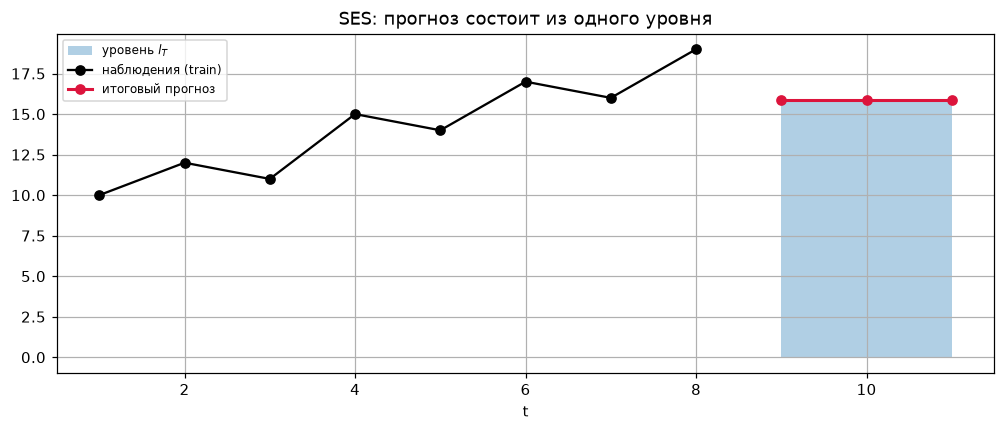

In [15]:
plot_forecast_decomposition(
    ses_fit.forecast(H_ses),
    [("уровень $l_T$", l_T, "base")],
    "SES: прогноз состоит из одного уровня",
    history=y_ses,
)
plt.show()

🔑 Прогноз SES на любое число шагов вперёд — **горизонтальная прямая**:
у модели просто нет компоненты, которая умела бы расти или падать. Годится
для рядов без выраженного тренда и сезонности; для остального — переходим
к моделям Хольта и Хольта-Винтерса в разделах 2 и 3.

Ещё раз целиком: фильтрация (fitted) слева от границы, прогноз — справа.

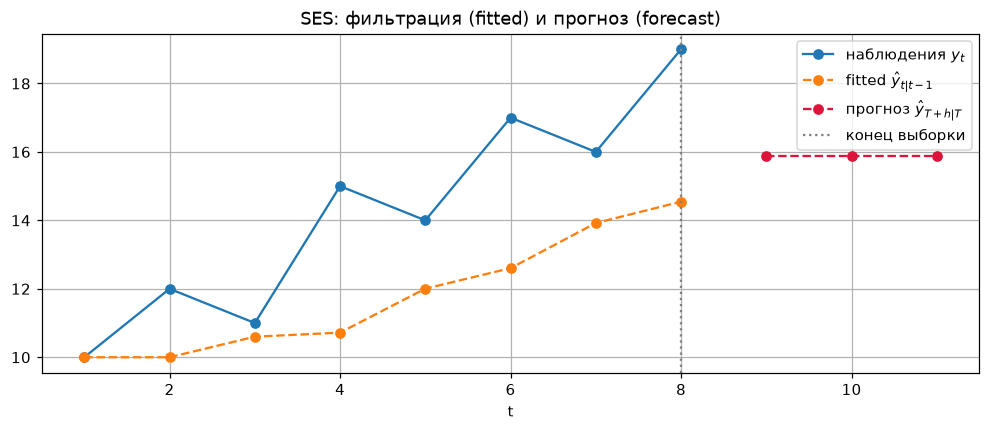

In [16]:
fig, ax = plt.subplots()
y_ses.plot(ax=ax, marker="o", label="наблюдения $y_t$")
ses_fit.fittedvalues.plot(ax=ax, marker="o", linestyle="--", label="fitted $\\hat{y}_{t|t-1}$")
ses_fit.forecast(H_ses).plot(
    ax=ax, marker="o", linestyle="--", color="crimson", label="прогноз $\\hat{y}_{T+h|T}$"
)
ax.axvline(y_ses.index[-1], color="gray", linestyle=":", label="конец выборки")
ax.set_title("SES: фильтрация (fitted) и прогноз (forecast)")
ax.legend()
plt.show()

## 1.6. Что делает `fit()` без фиксированных параметров

Мы искусственно зафиксировали $\alpha$ и $l_0$, чтобы свериться с ручным
расчётом. В обычной работе так не делают — параметры **оценивают** по
данным. По умолчанию `fit()` находит $\alpha$ и $l_0$, которые минимизируют
сумму квадратов одношаговых ошибок $\sum_t (y_t - \hat{y}_{t \mid t-1})^2$,
численной оптимизацией (это и есть MLE при гауссовской ошибке).

In [17]:
ses_auto = SimpleExpSmoothing(y_ses, initialization_method="estimated").fit()

print(f"Оценённый α:  {ses_auto.params['smoothing_level']:.4f}")
print(f"Оценённый l0: {ses_auto.params['initial_level']:.4f}")
print(f"SSE:          {ses_auto.sse:.4f}  (было {ses_fit.sse:.4f} при ручном α=0.3)")

Оценённый α:  0.7652
Оценённый l0: 10.4652
SSE:          36.6250  (было 69.9597 при ручном α=0.3)


🔍 `initialization_method` — это то, откуда берётся $l_0$ (и позже $b_0$,
сезонные индексы), а не параметр сглаживания:

| Метод | Как получают начальное состояние |
|---|---|
| `"known"` | вы задаёте `initial_level=`, `initial_trend=`, `initial_seasonal=` сами |
| `"heuristic"` | простая эвристика по первым наблюдениям (например, для уровня — первое значение ряда) |
| `"estimated"` (по умолчанию) | эвристика используется как стартовая точка, а дальше начальное состояние оценивается вместе с $\alpha$, $\beta$, $\gamma$ той же численной оптимизацией |

## 1.7. Влияние $\alpha$: инерция против чувствительности к шуму

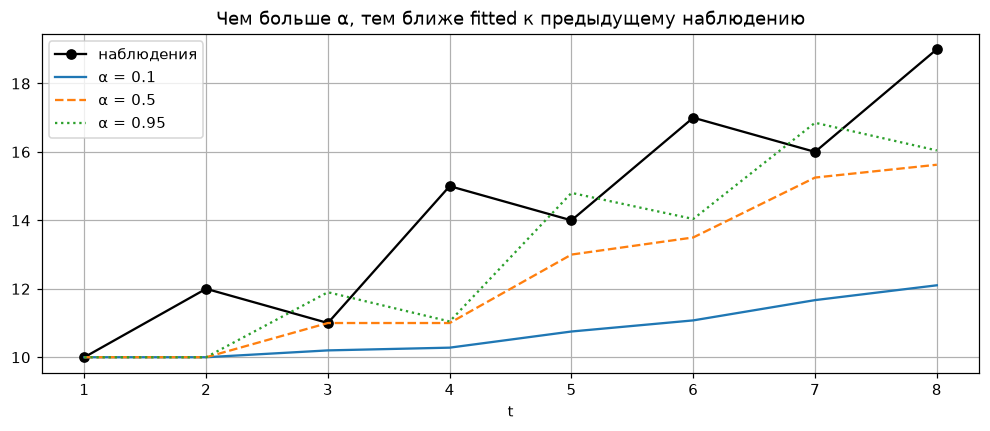

In [18]:
fig, ax = plt.subplots()
y_ses.plot(ax=ax, marker="o", color="black", label="наблюдения")
for a, style in zip([0.1, 0.5, 0.95], ["-", "--", ":"]):
    fit_a = SimpleExpSmoothing(y_ses, initialization_method="known", initial_level=l0).fit(
        smoothing_level=a, optimized=False
    )
    fit_a.fittedvalues.plot(ax=ax, linestyle=style, label=f"α = {a}")
ax.set_title("Чем больше α, тем ближе fitted к предыдущему наблюдению")
ax.legend()
plt.show()

При $\alpha = 0.95$ кривая fitted почти повторяет ряд со сдвигом на шаг —
модель почти не сглаживает шум. При $\alpha = 0.1$ кривая гораздо более
инертна: реагирует на изменения медленно, зато устойчива к случайным
выбросам.

---
# 2. Модель Хольта — ETS(A,A,N)

## 2.1. Теория

Модель Хольта добавляет вторую компоненту состояния — тренд $b_t$
(среднее изменение уровня за один шаг). Теперь два уравнения сглаживания:

$$
\begin{aligned}
\text{прогноз:} \quad & \hat{y}_{t+h \mid t} = l_t + h \, b_t \\
\text{сглаживание уровня:} \quad & l_t = \alpha y_t + (1-\alpha)(l_{t-1} + b_{t-1}) \\
\text{сглаживание тренда:} \quad & b_t = \beta^{*} (l_t - l_{t-1}) + (1-\beta^{*}) b_{t-1}
\end{aligned}
$$

Прогноз теперь не горизонтальная прямая, а **луч**: $l_t$ — точка отсчёта,
$b_t$ — наклон, и на $h$ шагов вперёд прибавляется $h$ раз подряд.

## 2.2. Рекурсия руками

In [19]:
y_holt = pd.Series(
    [10.0, 13.0, 15.0, 19.0, 21.0, 25.0],
    index=pd.RangeIndex(1, 7, name="t"),
    name="y",
)

# Параметры модели
alpha_h, beta_h = 0.4, 0.3
l0_h, b0_h = 9.0, 2.0

In [20]:
rows = []
l_prev, b_prev = l0_h, b0_h
for t, y_t in y_holt.items():
    y_hat_t = l_prev + b_prev  # прогноз на шаг вперёд ДО y_t
    e_t = y_t - y_hat_t  # ошибка прогноза
    l_t = alpha_h * y_t + (1 - alpha_h) * (l_prev + b_prev)
    b_t = beta_h * (l_t - l_prev) + (1 - beta_h) * b_prev
    rows.append({"t": t, "y_t": y_t, "ŷ_t": y_hat_t, "e_t": e_t, "l_t": l_t, "b_t": b_t})
    l_prev, b_prev = l_t, b_t

manual_holt = pd.DataFrame(rows).set_index("t")
manual_holt.round(4)

,y_t,ŷ_t,e_t,l_t,b_t
t,,,,,
1,10.0,11.0000,-1.0000,10.6000,1.8800
2,13.0,12.4800,0.5200,12.6880,1.9424
3,15.0,14.6304,0.3696,14.7782,1.9868
4,19.0,16.7650,2.2350,17.6590,2.2550
5,21.0,19.9139,1.0861,20.3484,2.3853
6,25.0,22.7336,2.2664,23.6402,2.6572


## 2.3. Сверяем фильтрацию с `Holt`

In [21]:
holt_model = Holt(y_holt, initialization_method="known", initial_level=l0_h, initial_trend=b0_h)
holt_fit = holt_model.fit(smoothing_level=alpha_h, smoothing_trend=beta_h, optimized=False)

sm_holt = pd.DataFrame(
    {
        "y": y_holt,
        "level": holt_fit.level,
        "trend": holt_fit.trend,
        "fittedvalues": holt_fit.fittedvalues,
        "resid": holt_fit.resid,
    },
)
sm_holt.round(4)

,y,level,trend,fittedvalues,resid
t,,,,,
1,10.0,10.6000,1.8800,11.0000,-1.0000
2,13.0,12.6880,1.9424,12.4800,0.5200
3,15.0,14.7782,1.9868,14.6304,0.3696
4,19.0,17.6590,2.2550,16.7650,2.2350
5,21.0,20.3484,2.3853,19.9139,1.0861
6,25.0,23.6402,2.6572,22.7336,2.2664


In [22]:
np.testing.assert_allclose(holt_fit.level.to_numpy(), manual_holt["l_t"].to_numpy())
np.testing.assert_allclose(holt_fit.trend.to_numpy(), manual_holt["b_t"].to_numpy())
np.testing.assert_allclose(holt_fit.fittedvalues.to_numpy(), manual_holt["ŷ_t"].to_numpy())
np.testing.assert_allclose(holt_fit.resid.to_numpy(), manual_holt["e_t"].to_numpy())
print("Совпало с ручным расчётом ✓")

Совпало с ручным расчётом ✓


`smoothing_trend` в `.params` — это наш $\beta^{*}$. 🔍 Атрибут `.trend`
у результата — это состояние $b_t$; не путайте с одноимённым **аргументом
конструктора** `trend=` у `ExponentialSmoothing` (раздел 3), который задаёт
*тип* тренда (`"add"`/`"mul"`), а не его текущее значение.

## 2.4. Прогноз руками и сверка

Прогноз на несколько шагов вперёд — луч из точки $l_T$ с наклоном $b_T$:
$\hat{y}_{T+h \mid T} = l_T + h\, b_T$. Состояние заморожено, меняется только
множитель $h$.

In [23]:
H_holt = 4
h_grid_holt = np.arange(1, H_holt + 1)
l_T_holt = manual_holt["l_t"].iloc[-1]
b_T_holt = manual_holt["b_t"].iloc[-1]

manual_holt_fc = pd.Series(
    l_T_holt + h_grid_holt * b_T_holt,
    index=pd.RangeIndex(7, 7 + H_holt, name="t"),
    name="ŷ (руками)",
)

compare_holt_fc = pd.DataFrame(
    {
        "h": h_grid_holt,
        "ŷ (руками)": manual_holt_fc,
        "ŷ (statsmodels)": holt_fit.forecast(H_holt).to_numpy(),
    }
)
print(f"l_T = {l_T_holt:.4f},  b_T = {b_T_holt:.4f}")
compare_holt_fc.round(4)

l_T = 23.6402,  b_T = 2.6572


,h,ŷ (руками),ŷ (statsmodels)
t,,,
7,1,26.2974,26.2974
8,2,28.9547,28.9547
9,3,31.6119,31.6119
10,4,34.2692,34.2692


In [24]:
np.testing.assert_allclose(holt_fit.forecast(H_holt).to_numpy(), manual_holt_fc.to_numpy())
print("Прогноз совпал с ручным расчётом ✓")

Прогноз совпал с ручным расчётом ✓


## 2.5. Разложение прогноза на компоненты

Теперь компонент две: постоянная опора $l_T$ и накапливающийся вклад тренда
$h\,b_T$, который и делает прогноз наклонным лучом. Ширина верхней полосы
растёт линейно по $h$ — это ровно то, из-за чего линейный тренд на длинном
горизонте становится рискованным.

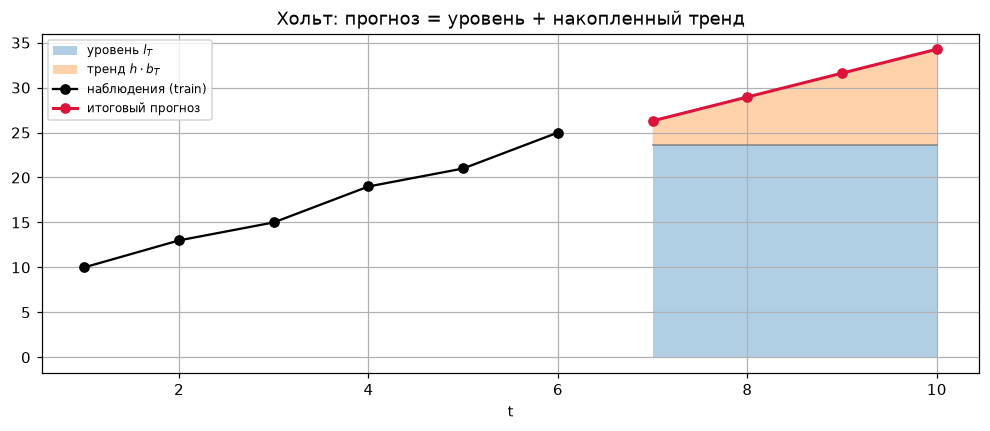

In [25]:
plot_forecast_decomposition(
    holt_fit.forecast(H_holt),
    [
        ("уровень $l_T$", l_T_holt, "base"),
        ("тренд $h \\cdot b_T$", h_grid_holt * b_T_holt, "add"),
    ],
    "Хольт: прогноз = уровень + накопленный тренд",
    history=y_holt,
)
plt.show()

## 2.6. Демпфированный тренд

Линейный тренд, продлённый на много шагов вперёд, часто выглядит неправдоподобно
оптимистично (или пессимистично). **Демпфирование** заставляет наклон
затухать к нулю с коэффициентом $\phi \in (0, 1)$:

$$ \hat{y}_{t+h \mid t} = l_t + (\phi + \phi^2 + \dots + \phi^h)\, b_t $$

При $h \to \infty$ сумма геометрической прогрессии сходится к $\phi / (1-\phi)$,
то есть прогноз выходит на асимптоту $l_t + \dfrac{\phi}{1-\phi} b_t$ вместо
бесконечного роста.

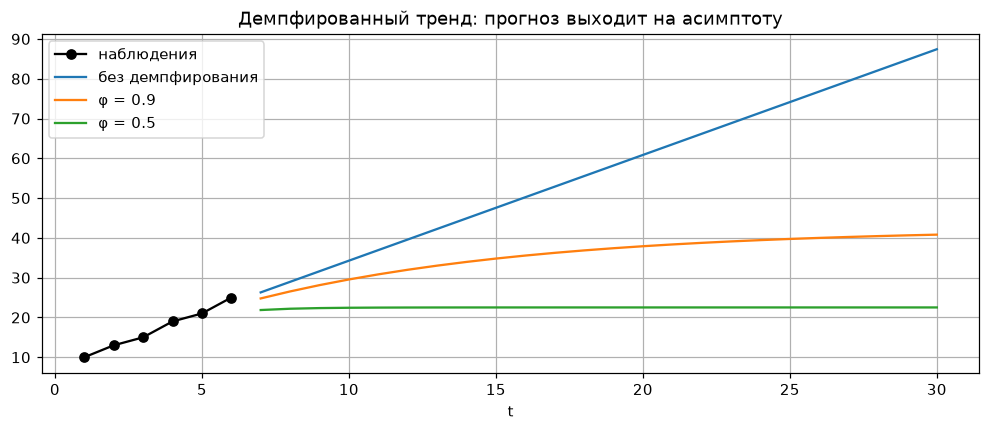

In [26]:
h_long = 24
fig, ax = plt.subplots()
y_holt.plot(ax=ax, marker="o", color="black", label="наблюдения")

for damped, phi, label in [
    (False, None, "без демпфирования"),
    (True, 0.9, "φ = 0.9"),
    (True, 0.5, "φ = 0.5"),
]:
    kwargs = {"smoothing_level": alpha_h, "smoothing_trend": beta_h, "optimized": False}
    if damped:
        kwargs["damping_trend"] = phi
    damped_model = Holt(
        y_holt,
        damped_trend=damped,
        initialization_method="known",
        initial_level=l0_h,
        initial_trend=b0_h,
    )
    damped_model.fit(**kwargs).forecast(h_long).plot(ax=ax, label=label)

ax.set_title("Демпфированный тренд: прогноз выходит на асимптоту")
ax.legend()
plt.show()

### Демпфирование руками

Проверим и эту версию по тому же шаблону. При демпфировании $\phi$ входит
**и в рекурсию фильтрации**, а не только в уравнение прогноза: всюду, где
раньше стоял $b_{t-1}$, теперь стоит $\phi\, b_{t-1}$.

$$
\begin{aligned}
\text{прогноз:} \quad & \hat{y}_{t+h \mid t} = l_t + (\phi + \dots + \phi^h) b_t \\
\text{уровень:} \quad & l_t = \alpha y_t + (1-\alpha)(l_{t-1} + \phi b_{t-1}) \\
\text{тренд:} \quad & b_t = \beta^{*}(l_t - l_{t-1}) + (1-\beta^{*}) \phi b_{t-1}
\end{aligned}
$$

In [27]:
phi_d = 0.9

rows = []
l_prev, b_prev = l0_h, b0_h
for t, y_t in y_holt.items():
    y_hat_t = l_prev + phi_d * b_prev
    e_t = y_t - y_hat_t
    l_t = alpha_h * y_t + (1 - alpha_h) * (l_prev + phi_d * b_prev)
    b_t = beta_h * (l_t - l_prev) + (1 - beta_h) * phi_d * b_prev
    rows.append({"t": t, "y_t": y_t, "ŷ_t": y_hat_t, "e_t": e_t, "l_t": l_t, "b_t": b_t})
    l_prev, b_prev = l_t, b_t

manual_damped = pd.DataFrame(rows).set_index("t")

damped_fit = Holt(
    y_holt,
    damped_trend=True,
    initialization_method="known",
    initial_level=l0_h,
    initial_trend=b0_h,
).fit(
    smoothing_level=alpha_h, smoothing_trend=beta_h, damping_trend=phi_d, optimized=False
)

np.testing.assert_allclose(damped_fit.level.to_numpy(), manual_damped["l_t"].to_numpy())
np.testing.assert_allclose(damped_fit.trend.to_numpy(), manual_damped["b_t"].to_numpy())
np.testing.assert_allclose(damped_fit.fittedvalues.to_numpy(), manual_damped["ŷ_t"].to_numpy())
print("Фильтрация совпала с ручным расчётом ✓")

Фильтрация совпала с ручным расчётом ✓


🔍 `.trend` у демпфированной модели — это **недемпфированное** состояние
$b_t$; множитель $\phi$ применяется уже при построении прогноза, поэтому в
ручном расчёте он появляется в двух местах: внутри рекурсии (как $\phi b_{t-1}$)
и в сумме $\phi + \dots + \phi^h$ уравнения прогноза.

In [28]:
l_T_d = manual_damped["l_t"].iloc[-1]
b_T_d = manual_damped["b_t"].iloc[-1]
# Накопленный множитель φ + φ² + ... + φ^h для каждого h.
damping_sum = np.cumsum(phi_d ** h_grid_holt)

manual_damped_fc = pd.Series(
    l_T_d + damping_sum * b_T_d,
    index=pd.RangeIndex(7, 7 + H_holt, name="t"),
    name="ŷ (руками)",
)

compare_damped_fc = pd.DataFrame(
    {
        "h": h_grid_holt,
        "φ + ... + φ^h": damping_sum,
        "ŷ (руками)": manual_damped_fc,
        "ŷ (statsmodels)": damped_fit.forecast(H_holt).to_numpy(),
    }
)
compare_damped_fc.round(4)

,h,φ + ... + φ^h,ŷ (руками),ŷ (statsmodels)
t,,,,
7,1,0.9000,24.7808,24.7808
8,2,1.7100,26.5397,26.5397
9,3,2.4390,28.1227,28.1227
10,4,3.0951,29.5475,29.5475


In [29]:
np.testing.assert_allclose(damped_fit.forecast(H_holt).to_numpy(), manual_damped_fc.to_numpy())
print("Прогноз совпал с ручным расчётом ✓")

Прогноз совпал с ручным расчётом ✓


Разложение демпфированного прогноза: вклад тренда теперь растёт не линейно,
а упирается в потолок $\frac{\phi}{1-\phi} b_T$ — полоса тренда выходит на
постоянную ширину.

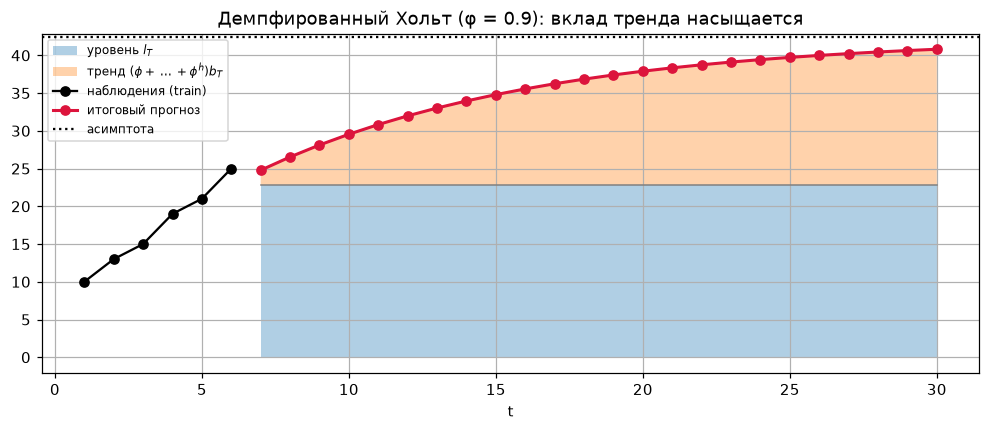

In [30]:
h_grid_long = np.arange(1, h_long + 1)
plot_forecast_decomposition(
    damped_fit.forecast(h_long),
    [
        ("уровень $l_T$", l_T_d, "base"),
        ("тренд $(\\phi + \\dots + \\phi^h) b_T$", np.cumsum(phi_d**h_grid_long) * b_T_d, "add"),
    ],
    f"Демпфированный Хольт (φ = {phi_d}): вклад тренда насыщается",
    history=y_holt,
)
plt.axhline(
    l_T_d + phi_d / (1 - phi_d) * b_T_d,
    color="black",
    linestyle=":",
    label="асимптота",
)
plt.legend(loc="upper left", fontsize=8)
plt.show()


## 2.7. Мультипликативный тренд — коротко

Помимо аддитивного тренда (постоянный прирост $b_t$ в единицах ряда), Holt
поддерживает мультипликативный (`exponential=True`): прогноз растёт не
линейно, а геометрически, $\hat{y}_{t+h|t} = l_t \cdot b_t^h$. Используют
редко и осторожно — при неудачных данных прогноз может улетать
экспоненциально быстро.

---
# 3. Модель Хольта-Винтерса — ETS(A,A,A) и ETS(A,A,M)

## 3.1. Теория

Добавляем третью компоненту состояния — сезонность: $m$ сезонных индексов
$s_t, s_{t-1}, \dots, s_{t-m+1}$, где $m$ — длина сезонного цикла (например,
12 для месячных данных с годовой сезонностью). Для **аддитивной** сезонности:

$$
\begin{aligned}
\text{прогноз:} \quad & \hat{y}_{t+h \mid t} = l_t + h\, b_t + s_{t + h - m\lceil h/m \rceil} \\
\text{уровень:} \quad & l_t = \alpha (y_t - s_{t-m}) + (1-\alpha)(l_{t-1} + b_{t-1}) \\
\text{тренд:} \quad & b_t = \beta^{*} (l_t - l_{t-1}) + (1-\beta^{*}) b_{t-1} \\
\text{сезон:} \quad & s_t = \gamma (y_t - l_{t-1} - b_{t-1}) + (1-\gamma) s_{t-m}
\end{aligned}
$$

Слагаемое $s_{t+h-m\lceil h/m \rceil}$ в уравнении прогноза выглядит громоздко,
но означает простую вещь: для прогноза на $h$ шагов вперёд берётся тот же
сезонный индекс, что был $m$ (один полный цикл) назад — сезонность **не
сглаживается заново** при каждом шаге прогноза, а просто копируется из
последнего известного цикла.

**Аддитивная** сезонность (`seasonal="add"`) — колебания одной и той же
амплитуды независимо от уровня ряда. **Мультипликативная** (`seasonal="mul"`) —
амплитуда колебаний растёт вместе с уровнем: сезонный индекс — множитель,
а не слагаемое, $\hat{y}_{t+h|t} = (l_t + h b_t) \cdot s_{t+h-m\lceil h/m\rceil}$.
Практическое правило: если на графике ряда сезонные «зубцы» становятся
заметно выше по мере роста тренда — нужна мультипликативная сезонность.

🔍 Каждый сезонный индекс $s_t$ обновляется по формуле выше на каждом шаге,
но реально «видит» новое наблюдение только раз в $m$ шагов — для остальных
$t$ он входит в прогноз как индекс годичной (или иной периодичности) давности.

## 3.2. Рекурсия руками на игрушечном ряде с периодом $m=4$

In [31]:
y_hw = pd.Series(
    [10.0, 14.0, 9.0, 6.0, 12.0, 16.0, 11.0, 8.0, 14.0, 18.0],
    index=pd.RangeIndex(1, 11, name="t"),
    name="y",
)
m = 4

# Параметры модели
alpha_w, beta_w, gamma_w = 0.3, 0.2, 0.3
l0_w, b0_w = 10.0, 0.5
# Начальные сезонные индексы для t = 0, -1, -2, -3 (в порядке s_0, s_{-1}, s_{-2}, s_{-3}):
s_init = {0: 0.0, -1: 4.0, -2: -1.0, -3: -3.0}

Распишем первые два шага, а дальше — тем же циклом, что и раньше.

**Шаг $t=1$.** Прогноз $\hat{y}_1 = l_0 + b_0 + s_{1-4} = 10.0 + 0.5 + s_{-3}
= 10.0 + 0.5 - 3.0 = 7.5$. Наблюдаем $y_1 = 10.0$, обновляем уровень
$l_1 = \alpha(y_1 - s_{-3}) + (1-\alpha)(l_0+b_0) = 0.3 \cdot 13.0 + 0.7
\cdot 10.5 = 11.25$, тренд $b_1 = \beta^{*}(l_1-l_0) + (1-\beta^{*})b_0
= 0.2 \cdot 1.25 + 0.8 \cdot 0.5 = 0.65$, сезон
$s_1 = \gamma(y_1 - l_0 - b_0) + (1-\gamma)s_{-3} = 0.3\cdot(-0.5) + 0.7
\cdot(-3.0) = -2.25$.

**Шаг $t=2$.** Тот же расчёт, но опорный сезонный индекс — уже $s_{2-4}=s_{-2}=-1.0$.

Дальше — тот же шаблон в цикле, только вместо словесных $s_{-3}, s_{-2}, \dots$
используем массив последних $m$ сезонных значений.

In [32]:
season_history = [
    s_init[-3],
    s_init[-2],
    s_init[-1],
    s_init[0],
]  # [s_{t-4}, ..., s_{t-1}] в момент t=1

rows = []
l_prev, b_prev = l0_w, b0_w
for t, y_t in y_hw.items():
    s_lag = season_history[0]  # сезонный индекс m шагов назад, т.е. s_{t-m}
    y_hat_t = l_prev + b_prev + s_lag
    e_t = y_t - y_hat_t
    l_t = alpha_w * (y_t - s_lag) + (1 - alpha_w) * (l_prev + b_prev)
    b_t = beta_w * (l_t - l_prev) + (1 - beta_w) * b_prev
    s_t = gamma_w * (y_t - l_prev - b_prev) + (1 - gamma_w) * s_lag
    rows.append(
        {"t": t, "y_t": y_t, "ŷ_t": y_hat_t, "e_t": e_t, "l_t": l_t, "b_t": b_t, "s_t": s_t}
    )
    l_prev, b_prev = l_t, b_t
    season_history = [*season_history[1:], s_t]  # сдвигаем окно на один сезон

manual_hw = pd.DataFrame(rows).set_index("t")
manual_hw.round(4)

,y_t,ŷ_t,e_t,l_t,b_t,s_t
t,,,,,,
1,10.0,7.5000,2.5000,11.2500,0.6500,-2.2500
2,14.0,10.9000,3.1000,12.8300,0.8360,-0.0700
3,9.0,17.6660,-8.6660,11.0662,0.3160,1.4002
4,6.0,11.3822,-5.3822,9.7676,-0.0069,-1.6147
5,12.0,7.5107,4.4893,11.1075,0.2625,-0.9032
6,16.0,11.2999,4.7001,12.7800,0.5445,1.3400
7,11.0,14.7246,-3.7246,12.2070,0.3210,0.2828
8,8.0,10.9134,-2.9134,11.6540,0.1462,-2.4887
9,14.0,10.8970,3.1030,12.7311,0.3324,0.0277


## 3.3. Сверяем фильтрацию со `statsmodels`

`ExponentialSmoothing` ожидает начальные сезонные индексы как массив длины
$m$, но внутренне использует его **позиционно**, а не по «содержательным»
номерам $t$: элемент `initial_seasonal[0]` подставляется как $s_{t-m}$ на
самом первом шаге, `initial_seasonal[1]` — на втором, и так далее. Это тот
же порядок, что и в нашем `season_history` — от «самого старого» к «самому
свежему», то есть $s_{-3}, s_{-2}, s_{-1}, s_0$.

In [33]:
hw_model = ExponentialSmoothing(
    y_hw,
    trend="add",
    seasonal="add",
    seasonal_periods=m,
    initialization_method="known",
    initial_level=l0_w,
    initial_trend=b0_w,
    initial_seasonal=[s_init[-3], s_init[-2], s_init[-1], s_init[0]],
)
hw_fit = hw_model.fit(
    smoothing_level=alpha_w, smoothing_trend=beta_w, smoothing_seasonal=gamma_w, optimized=False
)

sm_hw = pd.DataFrame(
    {
        "y": y_hw,
        "level": hw_fit.level,
        "trend": hw_fit.trend,
        "season": hw_fit.season,
        "fittedvalues": hw_fit.fittedvalues,
        "resid": hw_fit.resid,
    }
)
sm_hw.round(4)

,y,level,trend,season,fittedvalues,resid
t,,,,,,
1,10.0,11.2500,0.6500,-2.2500,7.5000,2.5000
2,14.0,12.8300,0.8360,-0.0700,10.9000,3.1000
3,9.0,11.0662,0.3160,1.4002,17.6660,-8.6660
4,6.0,9.7676,-0.0069,-1.6147,11.3822,-5.3822
5,12.0,11.1075,0.2625,-0.9032,7.5107,4.4893
6,16.0,12.7800,0.5445,1.3400,11.2999,4.7001
7,11.0,12.2070,0.3210,0.2828,14.7246,-3.7246
8,8.0,11.6540,0.1462,-2.4887,10.9134,-2.9134
9,14.0,12.7311,0.3324,0.0277,10.8970,3.1030


In [34]:
np.testing.assert_allclose(hw_fit.level.to_numpy(), manual_hw["l_t"].to_numpy())
np.testing.assert_allclose(hw_fit.trend.to_numpy(), manual_hw["b_t"].to_numpy())
np.testing.assert_allclose(hw_fit.season.to_numpy(), manual_hw["s_t"].to_numpy())
np.testing.assert_allclose(hw_fit.fittedvalues.to_numpy(), manual_hw["ŷ_t"].to_numpy())
np.testing.assert_allclose(hw_fit.resid.to_numpy(), manual_hw["e_t"].to_numpy())
print("Совпало с ручным расчётом ✓")

Совпало с ручным расчётом ✓


## 3.4. Прогноз руками и сверка

В уравнении прогноза $\hat{y}_{T+h \mid T} = l_T + h\, b_T +
s_{T+h-m\lceil h/m \rceil}$ уровень и тренд ведут себя как у Хольта,
а сезонная добавка просто **циклически повторяется**: на шагах
$h = 1, 2, \dots, m$ берутся сезонные индексы последнего полного цикла,
затем всё повторяется с начала. В коде это тот же `season_history`, который
остался после цикла фильтрации, — в нём лежат последние $m$ сезонных
индексов в порядке от самого старого к самому свежему.

In [35]:
H_hw = 6
h_grid_hw = np.arange(1, H_hw + 1)
l_T_hw = manual_hw["l_t"].iloc[-1]
b_T_hw = manual_hw["b_t"].iloc[-1]
season_cycle = np.array(season_history)  # [s_{T-m+1}, ..., s_T]

seasonal_part = season_cycle[(h_grid_hw - 1) % m]
manual_hw_fc = pd.Series(
    l_T_hw + h_grid_hw * b_T_hw + seasonal_part,
    index=pd.RangeIndex(11, 11 + H_hw, name="t"),
    name="ŷ (руками)",
)

compare_hw_fc = pd.DataFrame(
    {
        "h": h_grid_hw,
        "уровень+тренд": l_T_hw + h_grid_hw * b_T_hw,
        "сезон": seasonal_part,
        "ŷ (руками)": manual_hw_fc,
        "ŷ (statsmodels)": hw_fit.forecast(H_hw).to_numpy(),
    }
)
compare_hw_fc["разница"] = compare_hw_fc["ŷ (statsmodels)"] - compare_hw_fc["ŷ (руками)"]
compare_hw_fc.round(4)

,h,уровень+тренд,сезон,ŷ (руками),ŷ (statsmodels),разница
t,,,,,,
11,1,14.6906,0.2828,14.9734,14.9734,0.000
12,2,15.2387,-2.4887,12.7501,12.7501,0.000
13,3,15.7869,0.0277,15.8146,15.8146,0.000
14,4,16.3351,2.4190,18.7540,17.6751,-1.079
15,5,16.8832,0.2828,17.1660,17.1660,0.000
16,6,17.4314,-2.4887,14.9427,14.9427,-0.000


Совпало везде, кроме $h = m = 4$. Это не ошибка в нашем расчёте: 🔍 в
`tsa.holtwinters` (проверено на statsmodels 0.14) прогноз использует цикл
сезонных индексов $s_{T-m}, \dots, s_{T-1}$, то есть **самое свежее**
обновление $s_T$ в прогноз не попадает — вместо него на шаге $h = m$
подставляется значение на один цикл старше, $s_{T-m}$. Для $h$, не кратных
$m$, оба цикла дают один и тот же индекс, поэтому расхождение видно ровно
на шагах $h = m, 2m, \dots$

Проверим это численно: заменим в ручном расчёте один индекс — тот, что
соответствует $h = m$, — на значение предыдущего цикла.

In [36]:
# Цикл, которым фактически пользуется statsmodels: s_{T-m}, ..., s_{T-1}.
sm_season_cycle = np.r_[manual_hw["s_t"].iloc[-m - 1], season_cycle[:-1]]
print("наш цикл (учебник):   ", np.round(season_cycle, 4))
print("цикл statsmodels:     ", np.round(sm_season_cycle, 4))

manual_hw_fc_sm = pd.Series(
    l_T_hw + h_grid_hw * b_T_hw + sm_season_cycle[h_grid_hw % m],
    index=manual_hw_fc.index,
)
np.testing.assert_allclose(hw_fit.forecast(H_hw).to_numpy(), manual_hw_fc_sm.to_numpy())
print("Прогноз statsmodels воспроизведён руками ✓")

наш цикл (учебник):    [ 0.2828 -2.4887  0.0277  2.419 ]
цикл statsmodels:      [ 1.34    0.2828 -2.4887  0.0277]
Прогноз statsmodels воспроизведён руками ✓


Разница между двумя вариантами — один шаг сглаживания сезонности из $m$,
на практике она невелика; но знать о ней полезно, иначе ручная сверка
выглядит как необъяснимое расхождение. Дальше в разделах мы пользуемся
числами самой библиотеки.

## 3.5. Разложение прогноза на компоненты

У Хольта-Винтерса компонент три. Первые две ведут себя как в разделе 2
(опора + линейно накапливающийся тренд), третья — пилообразная сезонная
добавка, которая повторяется с периодом $m$ и не затухает с горизонтом.

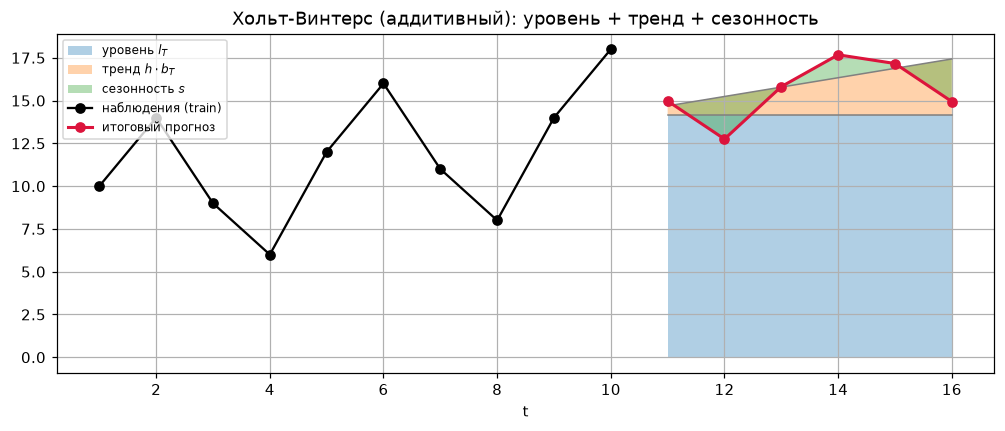

In [37]:
plot_forecast_decomposition(
    hw_fit.forecast(H_hw),
    [
        ("уровень $l_T$", l_T_hw, "base"),
        ("тренд $h \\cdot b_T$", h_grid_hw * b_T_hw, "add"),
        ("сезонность $s$", sm_season_cycle[h_grid_hw % m], "add"),
    ],
    "Хольт-Винтерс (аддитивный): уровень + тренд + сезонность",
    history=y_hw,
)
plt.show()

## 3.6. Реальные данные: `AirPassengers`

Игрушечный ряд был нужен, чтобы увидеть рекурсию по шагам. На практике
сезонность обычно ищут в данных с явным годовым циклом — возьмём классический
ряд числа авиапассажиров по месяцам.

Train: 1949-01-01 00:00:00 — 1959-12-01 00:00:00 (132 точек)
Test:  1960-01-01 00:00:00 — 1960-12-01 00:00:00 (12 точек)


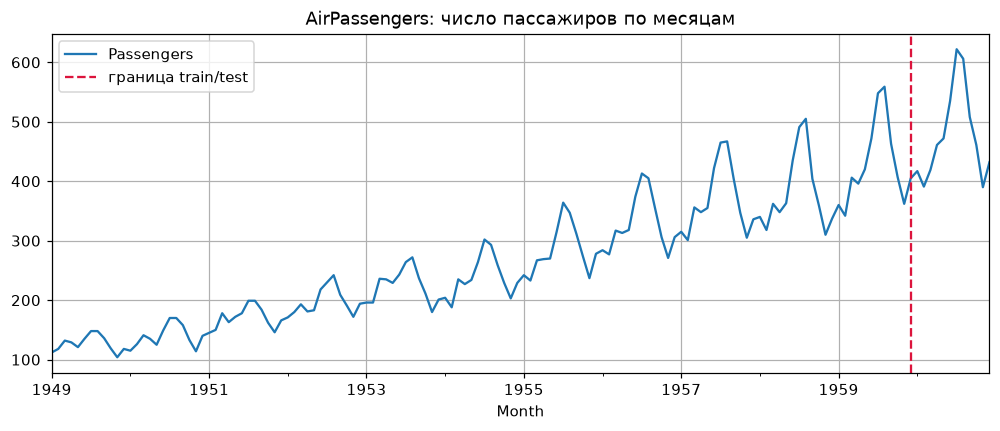

In [38]:
air = pd.read_csv(
    "https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_3/data/airline-passengers.csv",
    parse_dates=["Month"],
    index_col="Month",
)
air.index.freq = "MS"
air = air["Passengers"]

train, test = air.iloc[:132], air.iloc[132:]
print(f"Train: {train.index.min()} — {train.index.max()} ({len(train)} точек)")
print(f"Test:  {test.index.min()} — {test.index.max()} ({len(test)} точек)")

air.plot(title="AirPassengers: число пассажиров по месяцам")
plt.axvline(train.index[-1], color="crimson", linestyle="--", label="граница train/test")
plt.legend()
plt.show()

Амплитуда сезонных колебаний растёт вместе с уровнем ряда — визуальный
признак того, что здесь уместнее мультипликативная сезонность. Обучим обе
версии и сравним.

In [39]:
hw_add = ExponentialSmoothing(
    train, trend="add", seasonal="add", seasonal_periods=12, initialization_method="estimated"
).fit()
hw_mul = ExponentialSmoothing(
    train, trend="add", seasonal="mul", seasonal_periods=12, initialization_method="estimated"
).fit()

print(f"SSE, аддитивная сезонность:        {hw_add.sse:,.1f}")
print(f"SSE, мультипликативная сезонность: {hw_mul.sse:,.1f}")

SSE, аддитивная сезонность:        17,837.6
SSE, мультипликативная сезонность: 12,594.6


SSE у мультипликативной версии заметно ниже — она действительно лучше
описывает нарастающую амплитуду колебаний, что согласуется с картинкой выше.

## 3.7. Фильтрация: что модель думает о прошлом

Разложим ряд на компоненты состояния — это ответ на вопрос «что происходило
с уровнем, трендом и сезонностью на каждом шаге истории».

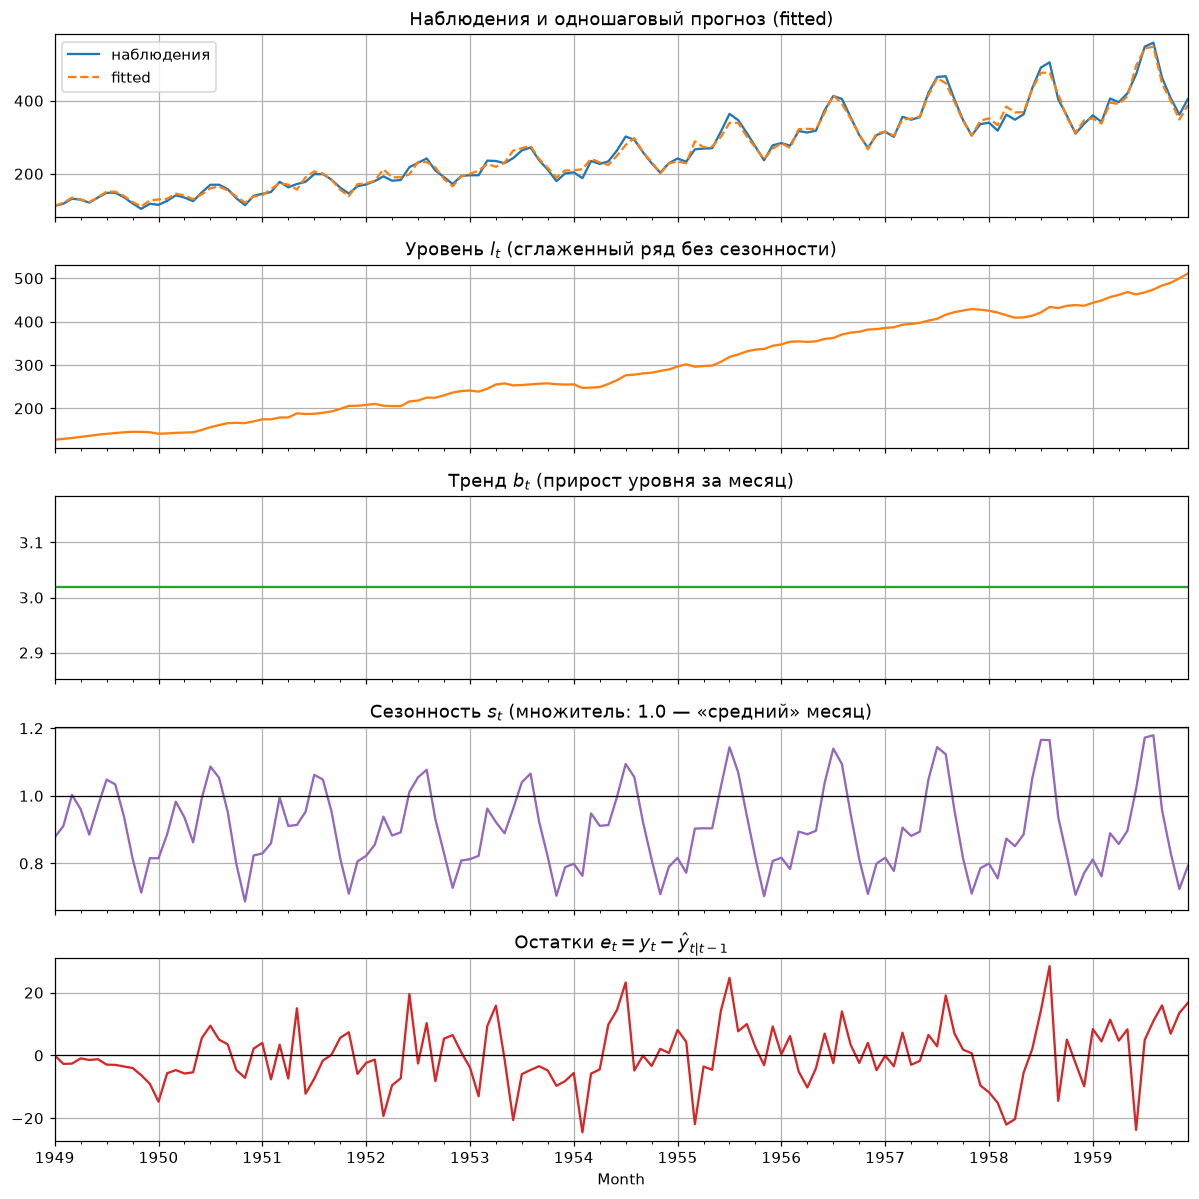

In [40]:
fig, axes = plt.subplots(5, 1, figsize=(11, 11), sharex=True)

train.plot(ax=axes[0], label="наблюдения")
hw_mul.fittedvalues.plot(ax=axes[0], label="fitted", linestyle="--")
axes[0].set_title("Наблюдения и одношаговый прогноз (fitted)")
axes[0].legend()

hw_mul.level.plot(ax=axes[1], color="tab:orange")
axes[1].set_title("Уровень $l_t$ (сглаженный ряд без сезонности)")

hw_mul.trend.plot(ax=axes[2], color="tab:green")
axes[2].set_title("Тренд $b_t$ (прирост уровня за месяц)")

hw_mul.season.plot(ax=axes[3], color="tab:purple")
axes[3].axhline(1, color="black", linewidth=0.8)
axes[3].set_title("Сезонность $s_t$ (множитель: 1.0 — «средний» месяц)")

hw_mul.resid.plot(ax=axes[4], color="tab:red")
axes[4].axhline(0, color="black", linewidth=0.8)
axes[4].set_title("Остатки $e_t = y_t - \\hat{y}_{t|t-1}$")

plt.tight_layout()
plt.show()

Это именно **фильтрация**: каждая точка на графиках уровня, тренда
и остатков вычислена с использованием наблюдений вплоть до этого момента
и ни одного наблюдения из будущего.

## 3.8. Прогноз: та же модель, замороженное состояние

Теперь — прогноз на 12 месяцев вперёд, то есть ровно на длину тестовой
выборки. Начиная с последнего момента train, наблюдений больше нет —
состояние $(l_T, b_T, s_T, \dots, s_{T-11})$ фиксируется, и уравнение
прогноза применяется 12 раз подряд без единого обновления по данным.

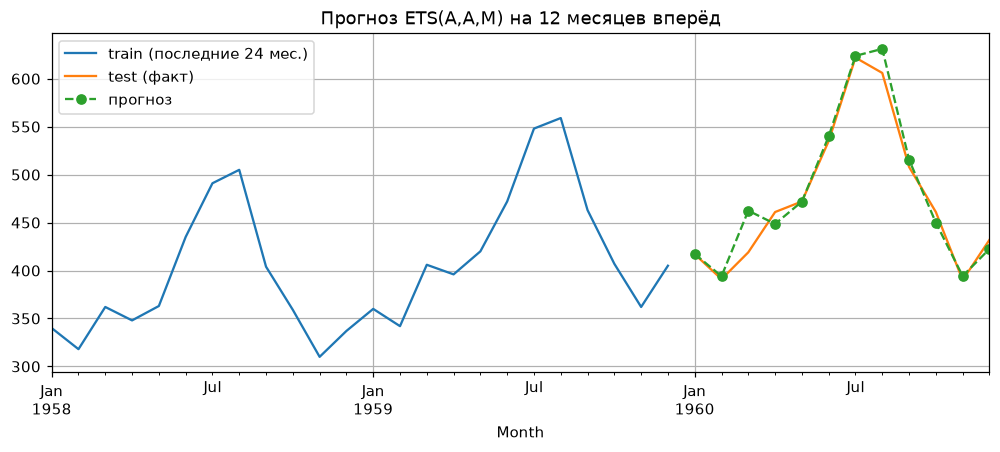

In [41]:
forecast_12 = hw_mul.forecast(12)

fig, ax = plt.subplots()
train.iloc[-24:].plot(ax=ax, label="train (последние 24 мес.)")
test.plot(ax=ax, label="test (факт)")
forecast_12.plot(ax=ax, linestyle="--", marker="o", label="прогноз")
ax.set_title("Прогноз ETS(A,A,M) на 12 месяцев вперёд")
ax.legend()
plt.show()

### Разложение прогноза на компоненты

Сверимся с уравнением прогноза и здесь. Сезонность мультипликативная, поэтому
формула выглядит так:

$$ \hat{y}_{T+h \mid T} = \underbrace{(l_T + h\, b_T)}_{\text{тренд-компонента}}
\cdot \underbrace{s_{T+h-m\lceil h/m\rceil}}_{\text{сезонный множитель}} $$

Тренд-компоненту считаем руками из состояния, а сезонный множитель на каждом
шаге получаем делением прогноза на неё — заодно проверяем, что он
действительно повторяет цикл из 12 чисел, а не меняется произвольно.

In [42]:
H_air = 12
h_grid_air = np.arange(1, H_air + 1)
l_T_air = hw_mul.level.iloc[-1]
b_T_air = hw_mul.trend.iloc[-1]

trend_part_air = l_T_air + h_grid_air * b_T_air
seasonal_factor_air = forecast_12.to_numpy() / trend_part_air

air_decomposition = pd.DataFrame(
    {
        "h": h_grid_air,
        "тренд-компонента $l_T + h b_T$": trend_part_air,
        "сезонный множитель": seasonal_factor_air,
        "прогноз": forecast_12.to_numpy(),
    },
    index=forecast_12.index,
)
air_decomposition.round(3)

,h,тренд-компонента $l_T + h b_T$,сезонный множитель,прогноз
1960-01-01,1,514.057,0.812,417.285
1960-02-01,2,517.075,0.762,394.062
1960-03-01,3,520.093,0.889,462.444
1960-04-01,4,523.112,0.858,448.598
1960-05-01,5,526.130,0.897,471.870
1960-06-01,6,529.148,1.020,539.893
1960-07-01,7,532.166,1.172,623.823
1960-08-01,8,535.185,1.179,631.154
1960-09-01,9,538.203,0.958,515.580
1960-10-01,10,541.221,0.831,449.902


Сезонные множители — это ровно последний полный цикл из `.season`
(с точностью до сдвига на один шаг, см. раздел 3.4): июль и август больше
единицы (пик отпусков), ноябрь и февраль — меньше.

In [43]:
print("сезонные множители из прогноза:", np.round(np.sort(seasonal_factor_air), 3))
print("последние 12 значений .season:  ", np.round(np.sort(hw_mul.season.iloc[-12:].to_numpy()), 3))

сезонные множители из прогноза: [0.724 0.762 0.772 0.812 0.831 0.858 0.889 0.897 0.958 1.02  1.172 1.179]
последние 12 значений .season:   [0.724 0.762 0.793 0.812 0.831 0.858 0.889 0.897 0.958 1.02  1.172 1.179]


/Users/a.p.chikov/PycharmProjects/time-series-cu-2026/week_3/.venv/lib/python3.11/site-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


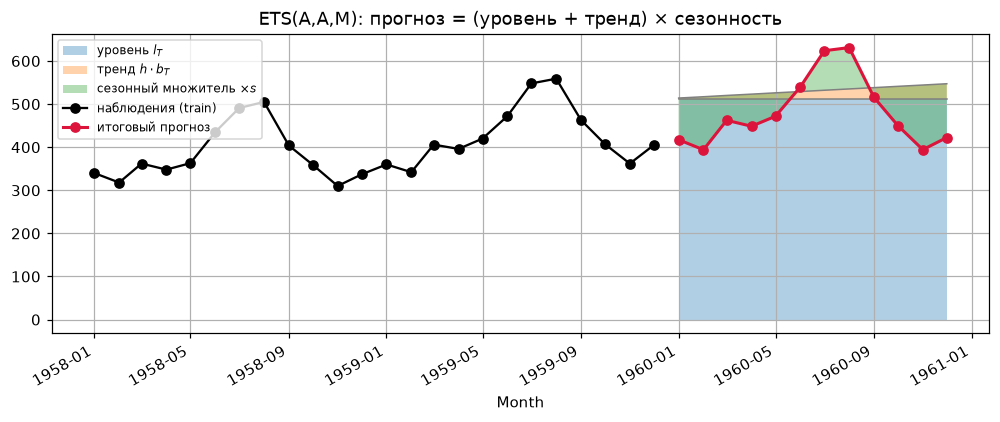

In [44]:
plot_forecast_decomposition(
    forecast_12,
    [
        ("уровень $l_T$", l_T_air, "base"),
        ("тренд $h \\cdot b_T$", h_grid_air * b_T_air, "add"),
        ("сезонный множитель $\\times s$", seasonal_factor_air, "mul"),
    ],
    "ETS(A,A,M): прогноз = (уровень + тренд) × сезонность",
    history=train.iloc[-24:],
)
plt.show()

🔍 Полоса сезонности здесь уходит и вверх, и вниз относительно
тренд-компоненты: множитель больше единицы растягивает прогноз вверх,
меньше единицы — прижимает вниз. В аддитивной модели (раздел 3.5) полоса
была бы той же формы, но одинаковой ширины на всём горизонте — в этом
и состоит разница между `seasonal="add"` и `seasonal="mul"`.

---
# 4. `ETSModel`: `summary()`, информационные критерии, интервалы

`tsa.holtwinters` научил нас читать рекурсию по шагам. Второй класс,
`ETSModel`, даёт то, чего в `holtwinters` нет: статистический отчёт,
информационные критерии для сравнения моделей и доверительные интервалы
прогноза. Обучим его на тех же данных, но добавим мультипликативную
**ошибку** (`error="mul"`) — компоненту, которую `tsa.holtwinters` вообще
не умеет оценивать.

In [45]:
ets_model = ETSModel(train, error="mul", trend="add", seasonal="mul", seasonal_periods=12)
ets_fit = ets_model.fit(disp=False)

print(ets_fit.summary())

                                 ETS Results                                  
Dep. Variable:             Passengers   No. Observations:                  132
Model:                       ETS(MAM)   Log Likelihood                -469.389
Date:                Mon, 21 Sep 2026   AIC                            974.778
Time:                        12:42:33   BIC                           1026.668
Sample:                    01-01-1949   HQIC                           995.864
                         - 12-01-1959   Scale                            0.001
Covariance Type:               approx                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
smoothing_level         0.9999      0.083     12.008      0.000       0.837       1.163
smoothing_trend      9.999e-05        nan        nan        nan         nan         nan
smoothing_season

## 4.1. Построчный разбор `summary()`

**Шапка.**

| Поле | Смысл |
|---|---|
| `Dep. Variable` | какой ряд моделируем |
| `Model: ETS(MAM)` | буквы читаются как Error=Mul, Trend=Add, Seasonal=Mul — ровно та таксономия из раздела 0.3 |
| `Log Likelihood` | логарифм правдоподобия в точке оптимума — чем больше (ближе к нулю), тем лучше модель объясняет данные *при равном числе параметров* |
| `AIC`, `BIC`, `AICC` | информационные критерии: логарифм правдоподобия со штрафом за число параметров. `AICC` — поправка AIC для малых выборок, предпочтительна при небольшом $T$ |
| `Sample` | диапазон дат, на которых обучена модель |

**Таблица коэффициентов** — это уже не «t-статистика значимости коэффициента
регрессии» в привычном смысле: параметры сглаживания живут в $[0,1]$, и то,
отличается ли $\alpha$ от нуля, редко содержательный вопрос (нулевой
$\alpha$ означал бы «уровень никогда не обновляется», что для реального
ряда почти никогда не так). Смотреть в этой таблице интереснее на сами
оценки `coef`, чем на `P>|z|`.

| Столбец | Смысл |
|---|---|
| `coef` | оценка параметра |
| `std err` | стандартная ошибка оценки |
| `z`, `P>\|z\|` | z-статистика и p-значение теста $H_0: \text{coef}=0$ |
| `[0.025, 0.975]` | 95%-й доверительный интервал для параметра |

Среди строк — `smoothing_level` ($\alpha$), `smoothing_trend` ($\beta^{*}$),
`smoothing_seasonal` ($\gamma$), `initial_level`, `initial_trend`, а также
`initial_seasonal.0`, …, `initial_seasonal.11` — по одному начальному
сезонному индексу на каждый из 12 месяцев цикла. При
`initialization_method="estimated"` (используется по умолчанию) все эти
начальные значения — не эвристика, а часть общей MLE-оптимизации, поэтому
у них тоже есть стандартная ошибка.

## 4.2. `.states` — состояние целиком одной таблицей

In [46]:
ets_fit.states.head(6)

,level,trend,seasonal
Month,,,
1949-01-01,111.999986,2.064377,1.000000
1949-02-01,119.883528,2.064959,0.984288
1949-03-01,116.916745,2.064455,1.129009
1949-04-01,119.252091,2.064483,1.081742
1949-05-01,112.149194,2.063566,1.078920
1949-06-01,110.488508,2.063193,1.221847


Столбцы — те же уровень/тренд/сезонность, что и `.level`/`.trend`/`.season`
у `tsa.holtwinters`, но собранные в один `DataFrame`: `level`, `trend`,
`seasonal`. Это ровно тот же единственный «текущий» сезонный индекс на
каждый момент времени, что и в `.season` у `tsa.holtwinters` — просто
другое имя столбца. 🔍 А вот в таблице коэффициентов `summary()` выше
перечислены **начальные** сезонные индексы `initial_seasonal.0 … .11` —
это другая вещь: не эволюция сезонности во времени, а $m$ чисел, с которых
сезонность стартовала перед первым наблюдением.

## 4.3. Доверительные интервалы прогноза

`tsa.holtwinters` не умеет строить интервалы прогноза вовсе — `.forecast()`
отдаёт только точечный прогноз. У `ETSModel` для этого есть `get_prediction()`.

In [47]:
pred = ets_fit.get_prediction(start=test.index[0], end=test.index[-1])
pred_summary = pred.summary_frame(alpha=0.05)
pred_summary.head()

,mean,mean_numerical,pi_lower,pi_upper
1960-01-01,412.842675,413.376108,384.603527,441.267128
1960-02-01,408.387538,408.635151,371.394643,448.024220
1960-03-01,470.771731,470.384891,416.960945,523.538674
1960-04-01,453.297712,453.330161,394.331838,516.424114
1960-05-01,454.348018,454.649646,391.261462,530.568588


* `mean` — точечный прогноз (то же самое, что вернул бы `.forecast(12)`);
* `pi_lower`, `pi_upper` — границы 95%-го (`alpha=0.05`) доверительного
  интервала прогноза.

По умолчанию `method="exact"` — интервал считается по аналитической формуле,
доступной для части моделей ETS. Альтернатива — `method="simulated"`:
интервал строится по эмпирическим квантилям множества случайных траекторий
(раздел 4.4).

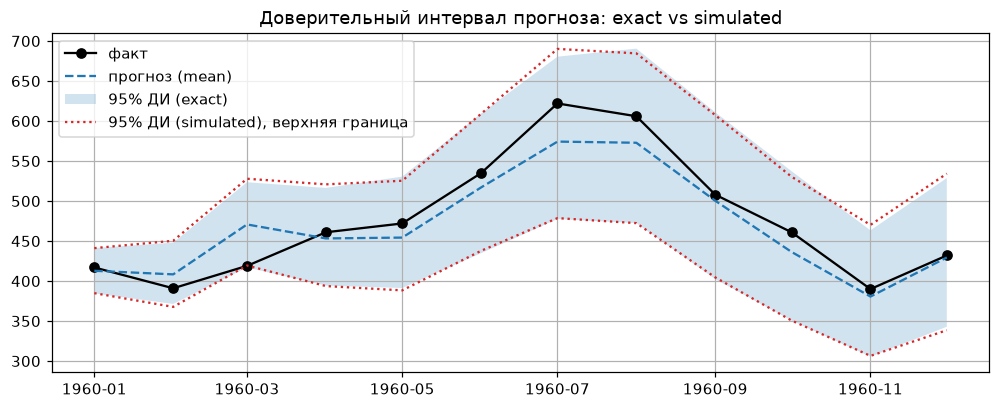

In [48]:
pred_sim = ets_fit.get_prediction(
    start=test.index[0], end=test.index[-1], method="simulated", simulate_repetitions=1000
)
pred_sim_summary = pred_sim.summary_frame(alpha=0.05)

fig, ax = plt.subplots()
ax.plot(test.index, test.values, marker="o", color="black", label="факт")
ax.plot(pred_summary.index, pred_summary["mean"], linestyle="--", label="прогноз (mean)")
ax.fill_between(
    pred_summary.index,
    pred_summary["pi_lower"],
    pred_summary["pi_upper"],
    alpha=0.2,
    label="95% ДИ (exact)",
)
ax.plot(
    pred_sim_summary.index,
    pred_sim_summary["pi_upper"],
    linestyle=":",
    color="tab:red",
    label="95% ДИ (simulated), верхняя граница",
)
ax.plot(
    pred_sim_summary.index,
    pred_sim_summary["pi_lower"], 
    linestyle=":",
    color="tab:red"
)
ax.set_title("Доверительный интервал прогноза: exact vs simulated")
ax.legend()
plt.show()

Границы `exact` и `simulated` близки, но не идентичны — второй способ
основан на случайных симуляциях (раздел 4.4) и имеет собственную
дисперсию оценки, которая уменьшается с ростом `simulate_repetitions`.

## 4.4. `simulate()`: прогноз — это распределение, а не линия

`.forecast()` и `mean` из `get_prediction()` — это единственная «средняя»
траектория. На деле модель ETS с ненулевой дисперсией ошибки описывает
целое распределение возможных будущих траекторий. `simulate()` генерирует
случайные примеры из этого распределения.

/Users/a.p.chikov/PycharmProjects/time-series-cu-2026/week_3/.venv/lib/python3.11/site-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)
/var/folders/p_/lhmc40f91qn_m64frv3rrz6h0000gq/T/ipykernel_10674/2643916586.py:6: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(


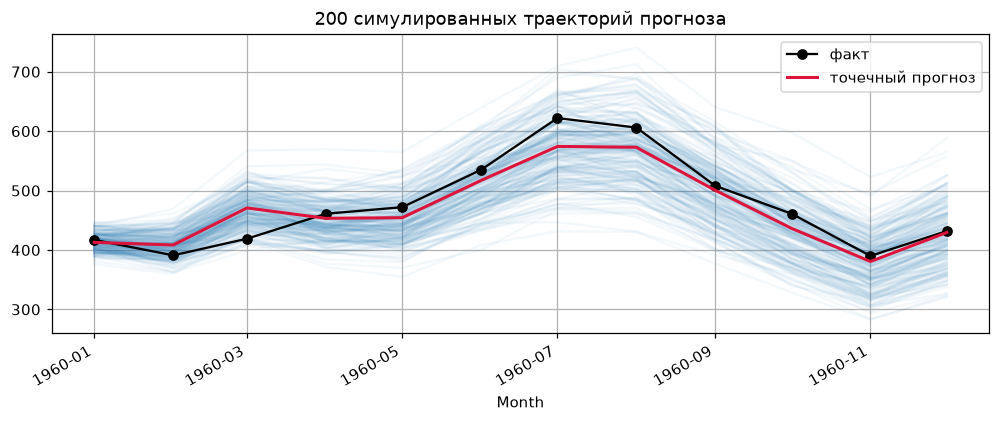

In [49]:
sim_paths = ets_fit.simulate(nsimulations=12, repetitions=200, anchor="end", random_state=0)

fig, ax = plt.subplots()
ax.plot(sim_paths.index, sim_paths.to_numpy(), color="tab:blue", alpha=0.05)
test.plot(ax=ax, marker="o", color="black", label="факт")
ax.plot(
    pred_summary.index, pred_summary["mean"], color="crimson", linewidth=2, label="точечный прогноз"
)
ax.set_title("200 симулированных траекторий прогноза")
ax.legend()
plt.show()

`anchor="end"` означает «начать симуляцию сразу после последнего
наблюдения train» — состояние, от которого стартуют все 200 траекторий,
то же самое замороженное состояние $(l_T, b_T, s_T, \dots)$ из раздела 3.5.
Разброс траекторий и есть источник доверительных интервалов при
`method="simulated"`.


---
# Итоги

## Что хотите узнать → куда смотреть

| Вопрос | Атрибут / метод | Класс |
|---|---|---|
| Текущий уровень/тренд/сезонность (фильтрация) | `.level`, `.trend`, `.season` | `tsa.holtwinters` |
| То же, одной таблицей | `.states` | `ETSModel` |
| Одношаговый прогноз в истории | `.fittedvalues` | оба |
| Ошибка одношагового прогноза | `.resid` | оба |
| Точечный прогноз за пределы выборки | `.forecast(h)` | оба |
| Прогноз с доверительным интервалом | `.get_prediction(...).summary_frame()` | `ETSModel` |
| Облако возможных траекторий | `.simulate(...)` | `ETSModel` |
| Оценки параметров, их значимость, AIC/BIC | `.summary()` | `ETSModel` |

## Уравнения прогноза, которые мы проверили руками

| Модель | $\hat{y}_{T+h \mid T}$ | Разложение прогноза |
|---|---|---|
| SES — ETS(A,N,N) | $l_T$ | одна компонента: горизонтальная прямая |
| Хольт — ETS(A,A,N) | $l_T + h\, b_T$ | уровень + линейно растущий вклад тренда |
| Хольт демпфированный | $l_T + (\phi + \dots + \phi^h) b_T$ | вклад тренда насыщается на $\frac{\phi}{1-\phi} b_T$ |
| Хольт-Винтерс — ETS(A,A,A) | $l_T + h\, b_T + s_{T+h-m\lceil h/m\rceil}$ | уровень + тренд + повторяющаяся сезонная добавка |
| Хольт-Винтерс — ETS(A,A,M) | $(l_T + h\, b_T) \cdot s_{T+h-m\lceil h/m\rceil}$ | (уровень + тренд), умноженные на сезонный множитель |

🔍 Единственное место, где ручной расчёт и `tsa.holtwinters` расходятся, —
сезонный индекс на шагах $h$, кратных $m$ (раздел 3.4): библиотека берёт
цикл $s_{T-m}, \dots, s_{T-1}$ и не использует самое свежее обновление $s_T$.
